<a href="https://colab.research.google.com/github/JessieMorozov/Early-Time-Nuclear-Accident-Classification-with-Correlation-Structured-Feature-Reduction/blob/main/nuclear_accident_feature_reduction_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early-Time Nuclear Accident Classification with Correlation-Structured Feature Reduction



## 1. Imports and configuration

In [ ]:

!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.5 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [ ]:
from pathlib import Path
import os
import glob
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from tslearn.early_classification import NonMyopicEarlyClassifier

global config

In [ ]:


RANDOM_STATE = 42

DATA_REPO_URL = "https://github.com/thu-inet/NuclearPowerPlantAccidentData"
DATA_REPO_DIR = Path("NuclearPowerPlantAccidentData")
OPERATION_BASE_PATH = DATA_REPO_DIR / "Operation_csv_data"

EXCLUDE_CLASSES = ["ATWS", "LACP", "LOF", "Normal", "SP", "TT"]


STEP = 10
T_MAX = 100
T_MAX_CORR = 4


DEAD_COLS = ["EBK", "MCRT", "MDBR", "MGAS", "QFCL", "QRHR", "TCRT"]
VAR_THRESHOLD = 1e-4
CORR_THRESHOLD = 0.90
LINKAGE_METHOD = "average"


NMEC_N_CLUSTERS = 3
NMEC_COST_TIME_PARAMETER = 1e-3
NMEC_LAMB = 1e2
NMEC_MIN_T = 1

## 2. Dataset setup

In [ ]:


if not DATA_REPO_DIR.exists():
    !git clone {DATA_REPO_URL}
else:
    print(f"Dataset directory already exists: {DATA_REPO_DIR}")

Cloning into 'NuclearPowerPlantAccidentData'...
remote: Enumerating objects: 6280, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 6280 (delta 86), reused 78 (delta 74), pack-reused 6146 (from 2)
Receiving objects: 100% (6280/6280), 290.79 MiB | 16.26 MiB/s, done.
Resolving deltas: 100% (4096/4096), done.
Updating files: 100% (6102/6102), done.


In [ ]:
def load_labeled_data(base_path, exclude_classes=None):

    base_path = Path(base_path)
    exclude_classes = set(exclude_classes or [])

    all_data = []
    all_labels = []

    for folder in sorted(os.listdir(base_path)):
        folder_path = base_path / folder

        if not folder_path.is_dir():
            continue

        if folder in exclude_classes:
            continue

        for csv_path in sorted(glob.glob(str(folder_path / "*.csv"))):
            try:
                df = pd.read_csv(csv_path)
                all_data.append(df)
                all_labels.append(folder)
            except Exception as exc:
                print(f"Error loading {csv_path}: {exc}")

    return all_data, all_labels

In [ ]:
all_data, all_labels = load_labeled_data(
    OPERATION_BASE_PATH,
    exclude_classes=EXCLUDE_CLASSES,
)

print("Number of simulations:", len(all_data))
print("Class counts:")
print(Counter(all_labels))
print("Example simulation shape:", all_data[0].shape)

Number of simulations: 1211
Class counts:
Counter({'SGBTR': 110, 'LLB': 101, 'SLBIC': 101, 'FLB': 100, 'LOCA': 100, 'LOCAC': 100, 'MD': 100, 'RI': 100, 'RW': 100, 'SGATR': 100, 'SLBOC': 100, 'LR': 99})
Example simulation shape: (553, 97)


## 3. Train / validation / test split

In [ ]:

X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_data,
    all_labels,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=all_labels,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_trainval,
)

print("Train:", len(X_train), Counter(y_train))
print("Val:  ", len(X_val), Counter(y_val))
print("Test: ", len(X_test), Counter(y_test))

Train: 726 Counter({'SGBTR': 66, 'SLBIC': 61, 'LOCA': 60, 'LLB': 60, 'RW': 60, 'SGATR': 60, 'FLB': 60, 'RI': 60, 'SLBOC': 60, 'LOCAC': 60, 'MD': 60, 'LR': 59})
Val:   242 Counter({'SGBTR': 22, 'SLBIC': 20, 'MD': 20, 'FLB': 20, 'LLB': 20, 'SGATR': 20, 'LOCAC': 20, 'RW': 20, 'LOCA': 20, 'SLBOC': 20, 'RI': 20, 'LR': 20})
Test:  243 Counter({'SGBTR': 22, 'LLB': 21, 'LOCA': 20, 'LR': 20, 'MD': 20, 'SLBOC': 20, 'LOCAC': 20, 'FLB': 20, 'RI': 20, 'SLBIC': 20, 'RW': 20, 'SGATR': 20})


## 4. Feature-space definition and fixed-length arrays

In [ ]:
def get_common_numeric_columns(df_list):
   #called on training data ONLY
    if len(df_list) == 0:
        raise ValueError("df_list is empty.")

    numeric_sets = []
    for df in df_list:
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        numeric_sets.append(set(numeric_cols))

    common = numeric_sets[0]
    for s in numeric_sets[1:]:
        common = common & s

    return sorted(common)


def df_to_fixed_length_array(df, cols, T_max=T_MAX, step=STEP):

    arr = df[cols].astype("float32").values
    arr = arr[::step]

    if arr.shape[0] == 0:
        raise ValueError("Simulation produced zero rows after downsampling.")

    if arr.shape[0] >= T_max:
        return arr[:T_max, :]

    pad_len = T_max - arr.shape[0]
    last_row = arr[-1:, :]
    pad = np.repeat(last_row, pad_len, axis=0)
    return np.vstack([arr, pad])

In [ ]:


common_numeric_cols = get_common_numeric_columns(X_train)

common_numeric_cols = [
    col for col in common_numeric_cols
    if col not in DEAD_COLS
]

print("Number of training-derived common numeric columns:", len(common_numeric_cols))

for split_name, split_data in [("validation", X_val), ("test", X_test)]:
    missing_any = []
    for i, df in enumerate(split_data):
        missing = set(common_numeric_cols) - set(df.columns)
        if missing:
            missing_any.append((i, sorted(missing)))
    if missing_any:
        raise ValueError(f"{split_name} split is missing training-derived columns: {missing_any[:3]}")
    print(f"{split_name} split contains all training-derived columns.")

Number of training-derived common numeric columns: 90
validation split contains all training-derived columns.
test split contains all training-derived columns.


In [ ]:
X_train_arr = np.stack([
    df_to_fixed_length_array(df, common_numeric_cols, T_max=T_MAX, step=STEP)
    for df in X_train
])

X_val_arr = np.stack([
    df_to_fixed_length_array(df, common_numeric_cols, T_max=T_MAX, step=STEP)
    for df in X_val
])

X_test_arr = np.stack([
    df_to_fixed_length_array(df, common_numeric_cols, T_max=T_MAX, step=STEP)
    for df in X_test
])

print("X_train_arr:", X_train_arr.shape)
print("X_val_arr:  ", X_val_arr.shape)
print("X_test_arr: ", X_test_arr.shape)
print("Any NaNs:", np.isnan(X_train_arr).any() or np.isnan(X_val_arr).any() or np.isnan(X_test_arr).any())

X_train_arr: (726, 100, 90)
X_val_arr:   (242, 100, 90)
X_test_arr:  (243, 100, 90)
Any NaNs: False


## 5. Scaling

In [ ]:
n_train, T_out, D = X_train_arr.shape
n_val = X_val_arr.shape[0]
n_test = X_test_arr.shape[0]

scaler = StandardScaler()

X_train_flat = X_train_arr.reshape(-1, D)
X_val_flat = X_val_arr.reshape(-1, D)
X_test_flat = X_test_arr.reshape(-1, D)

X_train_scaled = scaler.fit_transform(X_train_flat).reshape(n_train, T_out, D)
X_val_scaled = scaler.transform(X_val_flat).reshape(n_val, T_out, D)
X_test_scaled = scaler.transform(X_test_flat).reshape(n_test, T_out, D)

print("Scaled shapes:")
print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Scaled shapes:
(726, 100, 90) (242, 100, 90) (243, 100, 90)


## 6. Model wrappers for time-series input

In [ ]:
class TimeSeriesRandomForestClassifier(RandomForestClassifier):


    def _flatten_for_inference(self, X):
        if isinstance(X, list):
            X_array = X[0]
            return X_array.reshape(1, -1)

        if getattr(X, "ndim", 1) == 3:
            n_samples = X.shape[0]
            return X.reshape(n_samples, -1)

        if getattr(X, "ndim", 1) == 1:
            return X.reshape(1, -1)

        return X

    def fit(self, X, y, sample_weight=None):
        X_flat = self._flatten_for_inference(X)
        return super().fit(X_flat, y, sample_weight=sample_weight)

    def predict(self, X):
        X_flat = self._flatten_for_inference(X)
        return super().predict(X_flat)

    def predict_proba(self, X):
        X_flat = self._flatten_for_inference(X)
        return super().predict_proba(X_flat)


class TimeSeriesDecisionTreeClassifier(DecisionTreeClassifier):


    def _flatten_for_inference(self, X):
        if isinstance(X, list):
            X_array = X[0]
            return X_array.reshape(1, -1)

        if getattr(X, "ndim", 1) == 3:
            n_samples = X.shape[0]
            return X.reshape(n_samples, -1)

        if getattr(X, "ndim", 1) == 1:
            return X.reshape(1, -1)

        return X

    def fit(self, X, y, sample_weight=None):
        X_flat = self._flatten_for_inference(X)
        return super().fit(X_flat, y, sample_weight=sample_weight)

    def predict(self, X):
        X_flat = self._flatten_for_inference(X)
        return super().predict(X_flat)

    def predict_proba(self, X):
        X_flat = self._flatten_for_inference(X)
        return super().predict_proba(X_flat)

## 7. Training-only near-constant feature removal

In [ ]:
def drop_low_variance_features_3d(
    X_all,
    feature_names,
    t_max_decision=None,
    var_threshold=1e-4,
    verbose=True,
):

    n_samples, T, n_features = X_all.shape

    if len(feature_names) != n_features:
        raise ValueError("feature_names length mismatch.")

    if t_max_decision is not None:
        T_used = min(T, t_max_decision)
        X_window = X_all[:, :T_used, :]
    else:
        X_window = X_all

    X_flat = X_window.reshape(-1, n_features)
    variances = np.var(X_flat, axis=0)

    keep_mask = variances > var_threshold

    kept_feature_names = [
        feature_names[i]
        for i in np.where(keep_mask)[0]
    ]

    dropped_features_info = [
        (feature_names[i], float(variances[i]))
        for i in np.where(~keep_mask)[0]
    ]

    if verbose:
        print(f"Original features: {n_features}")
        print(f"Kept features:     {len(kept_feature_names)}")
        print(f"Dropped features:  {len(dropped_features_info)}")
        for name, var_val in dropped_features_info:
            print(f"  {name:25s} var={var_val:.6e}")

    return keep_mask, kept_feature_names, dropped_features_info

In [ ]:

variance_keep_mask, feature_names_clean, dropped_info = drop_low_variance_features_3d(
    X_train_scaled,
    common_numeric_cols,
    t_max_decision=T_MAX_CORR,
    var_threshold=VAR_THRESHOLD,
)


X_train_scaled_clean = X_train_scaled[:, :, variance_keep_mask]
X_val_scaled_clean = X_val_scaled[:, :, variance_keep_mask]
X_test_scaled_clean = X_test_scaled[:, :, variance_keep_mask]

print("Cleaned shapes:")
print(X_train_scaled_clean.shape, X_val_scaled_clean.shape, X_test_scaled_clean.shape)

Original features: 90
Kept features:     81
Dropped features:  9
  CNH2                      var=1.144172e-11
  FRCL                      var=1.205438e-11
  FRZR                      var=1.728397e-11
  MH2                       var=1.740830e-11
  RC131                     var=5.661626e-05
  TDBR                      var=2.909688e-11
  TSLP                      var=3.517199e-11
  WSPY                      var=1.398930e-11
  WUP                       var=1.932322e-11
Cleaned shapes:
(726, 100, 81) (242, 100, 81) (243, 100, 81)


## 8. Training-only Pearson correlation clustering

In [ ]:
def cluster_features_by_pearson(
    X_3d,
    feature_names,
    t_max_corr=None,
    corr_threshold=0.90,
    linkage_method="average",
    plot_dendrogram=True,
    figsize=(10, 5),
):

    if X_3d.ndim != 3:
        raise ValueError("X_3d must be 3D: (n_samples, T, n_features).")

    n_samples, T, n_features = X_3d.shape

    if len(feature_names) != n_features:
        raise ValueError("feature_names length mismatch.")

    if t_max_corr is not None:
        T_used = min(T, t_max_corr)
        X_window = X_3d[:, :T_used, :]
    else:
        X_window = X_3d

    X_flat = X_window.reshape(-1, n_features)

    if np.isnan(X_flat).any():
        raise ValueError("NaNs found before clustering.")

    corr_matrix = np.corrcoef(X_flat, rowvar=False)
    corr_matrix = np.clip(corr_matrix, -1.0, 1.0)

    distance_matrix = 1.0 - np.abs(corr_matrix)
    np.fill_diagonal(distance_matrix, 0.0)

    dist_condensed = squareform(distance_matrix, checks=False)
    Z = linkage(dist_condensed, method=linkage_method)

    max_distance = 1.0 - corr_threshold
    cluster_labels = fcluster(Z, t=max_distance, criterion="distance")

    clusters = {}
    for fname, cid in zip(feature_names, cluster_labels):
        clusters.setdefault(int(cid), []).append(fname)

    if plot_dendrogram:
        plt.figure(figsize=figsize)
        dendrogram(
            Z,
            labels=feature_names,
            orientation="left",
            leaf_font_size=8,
        )
        plt.title(f"Feature Clustering: distance = 1 - |r|, threshold={corr_threshold}")
        plt.xlabel("Distance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

    return corr_matrix, clusters, cluster_labels

In [ ]:
corr_matrix, clusters, cluster_labels = cluster_features_by_pearson(
    X_3d=X_train_scaled_clean,
    feature_names=feature_names_clean,
    t_max_corr=T_MAX_CORR,
    corr_threshold=CORR_THRESHOLD,
    linkage_method=LINKAGE_METHOD,
    plot_dendrogram=False,
)

print("Number of clusters:", len(clusters))

largest_clusters = sorted(
    clusters.items(),
    key=lambda kv: len(kv[1]),
    reverse=True,
)[:10]

for cid, feats in largest_clusters:
    suffix = " ..." if len(feats) > 8 else ""
    print(f"Cluster {cid:>3}: n={len(feats):>2}  {feats[:8]}{suffix}")

Number of clusters: 30
Cluster  14: n=27  ['DNBR', 'LSGA', 'LSGB', 'LVPZ', 'PWNT', 'PWR', 'QMGA', 'QMGB'] ...
Cluster  17: n= 5  ['MBK', 'PRB', 'PRBA', 'TRB', 'WCSP']
Cluster  12: n= 5  ['RRCA', 'RRCB', 'RRCO', 'WRCA', 'WRCB']
Cluster   3: n= 3  ['DTHY', 'DWB', 'RM4']
Cluster  20: n= 3  ['P', 'TSAT', 'VOL']
Cluster   6: n= 3  ['RM2', 'RM3', 'STTB']
Cluster   1: n= 3  ['STSG', 'WRLA', 'WRLB']
Cluster  10: n= 2  ['HLW', 'LVCR']
Cluster  13: n= 2  ['NSGA', 'NSGB']
Cluster  26: n= 2  ['PPM', 'RHBR']


## 9. NMEC evaluation helpers

In [ ]:
def make_nmec_classifier(rf_seed=0):
    return NonMyopicEarlyClassifier(
        base_classifier=TimeSeriesRandomForestClassifier(random_state=rf_seed),
        n_clusters=NMEC_N_CLUSTERS,
        cost_time_parameter=NMEC_COST_TIME_PARAMETER,
        lamb=NMEC_LAMB,
        min_t=NMEC_MIN_T,
        random_state=0,
    )


def fit_nmec_predict(Xtr, ytr, Xeval, rf_seed=0):
    clf = make_nmec_classifier(rf_seed=rf_seed)
    clf.fit(Xtr, ytr)
    return clf, clf.predict(Xeval)


def features_from_keep_clusters(clusters_dict, keep_cluster_ids):
    feats = set()
    for cid in keep_cluster_ids:
        feats.update(clusters_dict[int(cid)])
    return sorted(feats)


def mask_from_features(feature_names, keep_features):
    keep_set = set(keep_features)
    return np.array([f in keep_set for f in feature_names], dtype=bool)


def evaluate_feature_set(
    keep_features,
    Xtr,
    ytr,
    Xeval,
    yeval,
    feature_names,
    rf_seed=0,
):
    mask = mask_from_features(feature_names, keep_features)

    Xtr_subset = Xtr[:, :, mask]
    Xeval_subset = Xeval[:, :, mask]

    clf, y_pred = fit_nmec_predict(
        Xtr_subset,
        ytr,
        Xeval_subset,
        rf_seed=rf_seed,
    )

    return {
        "clf": clf,
        "mask": mask,
        "y_pred": y_pred,
        "n_features": int(mask.sum()),
        "accuracy": float(accuracy_score(yeval, y_pred)),
        "macro_f1": float(f1_score(yeval, y_pred, average="macro")),
    }

## 10. Validation-based cluster selection

In [ ]:

all_clean_features = list(feature_names_clean)

baseline_val = evaluate_feature_set(
    keep_features=all_clean_features,
    Xtr=X_train_scaled_clean,
    ytr=y_train,
    Xeval=X_val_scaled_clean,
    yeval=y_val,
    feature_names=feature_names_clean,
    rf_seed=0,
)

print(f"Baseline validation accuracy: {baseline_val['accuracy']:.4f}")
print(f"Baseline validation macro F1: {baseline_val['macro_f1']:.4f}")
print(f"Baseline feature count:       {baseline_val['n_features']}")

Baseline validation accuracy: 0.9876
Baseline validation macro F1: 0.9874
Baseline feature count:       81


In [ ]:


cluster_ablation_rows = []

for cid, cluster_feats in sorted(clusters.items()):
    keep_features = [
        f for f in feature_names_clean
        if f not in set(cluster_feats)
    ]

    result = evaluate_feature_set(
        keep_features=keep_features,
        Xtr=X_train_scaled_clean,
        ytr=y_train,
        Xeval=X_val_scaled_clean,
        yeval=y_val,
        feature_names=feature_names_clean,
        rf_seed=0,
    )

    cluster_ablation_rows.append({
        "cluster_id": int(cid),
        "cluster_size": len(cluster_feats),
        "val_accuracy_without_cluster": result["accuracy"],
        "val_macro_f1_without_cluster": result["macro_f1"],
        "accuracy_drop": baseline_val["accuracy"] - result["accuracy"],
        "macro_f1_drop": baseline_val["macro_f1"] - result["macro_f1"],
    })

cluster_ablation_df = pd.DataFrame(cluster_ablation_rows).sort_values(
    by=["accuracy_drop", "macro_f1_drop", "cluster_size"],
    ascending=[False, False, False],
)

cluster_ablation_df.head(15)

,cluster_id,cluster_size,val_accuracy_without_cluster,val_macro_f1_without_cluster,accuracy_drop,macro_f1_drop
5,6,3,0.913223,0.884720,0.074380,0.102660
3,4,2,0.962810,0.962118,0.024793,0.025261
1,2,1,0.983471,0.983073,0.004132,0.004307
23,24,1,0.983471,0.983175,0.004132,0.004205
24,25,2,0.983471,0.983272,0.004132,0.004108
0,1,3,0.987603,0.987380,0.000000,0.000000
18,19,2,0.987603,0.987380,0.000000,0.000000
22,23,2,0.987603,0.987380,0.000000,0.000000
4,5,1,0.987603,0.987380,0.000000,0.000000
17,18,1,0.987603,0.987380,0.000000,0.000000


In [ ]:
ranked_cluster_ids = cluster_ablation_df["cluster_id"].tolist()

print("Ranked cluster IDs:")
print(ranked_cluster_ids)

Ranked cluster IDs:
[6, 4, 2, 24, 25, 1, 19, 23, 5, 18, 28, 30, 27, 14, 20, 12, 11, 15, 16, 10, 13, 7, 9, 21, 22, 3, 26, 29, 17, 8]


In [ ]:


EPSILON = 0.02

incremental_rows = []
best_candidate = None

for k in range(1, len(ranked_cluster_ids) + 1):
    keep_cluster_ids = ranked_cluster_ids[:k]
    keep_features = features_from_keep_clusters(clusters, keep_cluster_ids)

    result = evaluate_feature_set(
        keep_features=keep_features,
        Xtr=X_train_scaled_clean,
        ytr=y_train,
        Xeval=X_val_scaled_clean,
        yeval=y_val,
        feature_names=feature_names_clean,
        rf_seed=0,
    )

    row = {
        "k_clusters": k,
        "keep_cluster_ids": keep_cluster_ids,
        "n_features": result["n_features"],
        "val_accuracy": result["accuracy"],
        "val_macro_f1": result["macro_f1"],
    }
    incremental_rows.append(row)

    if (
        best_candidate is None
        and result["accuracy"] >= baseline_val["accuracy"] - EPSILON
    ):
        best_candidate = row

incremental_df = pd.DataFrame(incremental_rows)
incremental_df

/usr/local/lib/python3.12/dist-packages/tslearn/early_classification/early_classification.py:280: RuntimeWarning: invalid value encountered in divide
  delta_k = 1. - distances_clusters / average_distance
/usr/local/lib/python3.12/dist-packages/tslearn/early_classification/early_classification.py:280: RuntimeWarning: invalid value encountered in divide
  delta_k = 1. - distances_clusters / average_distance
/usr/local/lib/python3.12/dist-packages/tslearn/early_classification/early_classification.py:280: RuntimeWarning: invalid value encountered in divide
  delta_k = 1. - distances_clusters / average_distance
/usr/local/lib/python3.12/dist-packages/tslearn/early_classification/early_classification.py:280: RuntimeWarning: invalid value encountered in divide
  delta_k = 1. - distances_clusters / average_distance
/usr/local/lib/python3.12/dist-packages/tslearn/early_classification/early_classification.py:280: RuntimeWarning: invalid value encountered in divide
  delta_k = 1. - distances_clu

,k_clusters,keep_cluster_ids,n_features,val_accuracy,val_macro_f1
0,1,[6],3,0.082645,0.012723
1,2,"[6, 4]",5,0.776860,0.746517
2,3,"[6, 4, 2]",6,0.863636,0.856401
3,4,"[6, 4, 2, 24]",7,0.925620,0.926723
4,5,"[6, 4, 2, 24, 25]",9,0.962810,0.963067
5,6,"[6, 4, 2, 24, 25, 1]",12,0.958678,0.959203
6,7,"[6, 4, 2, 24, 25, 1, 19]",14,0.958678,0.959299
7,8,"[6, 4, 2, 24, 25, 1, 19, 23]",16,0.954545,0.955611
8,9,"[6, 4, 2, 24, 25, 1, 19, 23, 5]",17,0.942149,0.943485
9,10,"[6, 4, 2, 24, 25, 1, 19, 23, 5, 18]",18,0.942149,0.943021


In [ ]:
if best_candidate is None:

    best_candidate = max(
        incremental_rows,
        key=lambda row: (row["val_accuracy"], row["val_macro_f1"], -row["n_features"]),
    )

selected_cluster_ids = best_candidate["keep_cluster_ids"]
selected_features = features_from_keep_clusters(clusters, selected_cluster_ids)
selected_mask = mask_from_features(feature_names_clean, selected_features)

print("Selected cluster IDs:", selected_cluster_ids)
print("Selected feature count:", len(selected_features))
print("Selected validation accuracy:", best_candidate["val_accuracy"])
print("Selected validation macro F1:", best_candidate["val_macro_f1"])
print("Selected features:")
print(selected_features)

Selected cluster IDs: [6, 4, 2, 24, 25, 1, 19, 23, 5, 18, 28, 30]
Selected feature count: 20
Selected validation accuracy: 0.9793388429752066
Selected validation macro F1: 0.9793614610687781
Selected features:
['HTR', 'LWRB', 'PSGA', 'PSGB', 'RBLK', 'RM1', 'RM2', 'RM3', 'SGLK', 'STSG', 'STTB', 'TIME', 'VOID', 'WBK', 'WCFT', 'WECS', 'WFLB', 'WLPI', 'WRLA', 'WRLB']


## 11. Final held-out test evaluation

In [ ]:


X_trainval_scaled_clean = np.concatenate(
    [X_train_scaled_clean, X_val_scaled_clean],
    axis=0,
)
y_trainval_final = list(y_train) + list(y_val)

X_trainval_selected = X_trainval_scaled_clean[:, :, selected_mask]
X_test_selected = X_test_scaled_clean[:, :, selected_mask]

final_clf = make_nmec_classifier(rf_seed=0)
final_clf.fit(X_trainval_selected, y_trainval_final)

y_test_pred = final_clf.predict(X_test_selected)

test_acc = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")

print(f"Final held-out test accuracy: {test_acc:.4f}")
print(f"Final held-out test macro F1: {test_macro_f1:.4f}")
print()
print(classification_report(y_test, y_test_pred))

Final held-out test accuracy: 0.9753
Final held-out test macro F1: 0.9757

              precision    recall  f1-score   support

         FLB       1.00      1.00      1.00        20
         LLB       1.00      1.00      1.00        21
        LOCA       1.00      1.00      1.00        20
       LOCAC       1.00      1.00      1.00        20
          LR       1.00      0.95      0.97        20
          MD       0.91      1.00      0.95        20
          RI       0.95      1.00      0.98        20
          RW       1.00      0.95      0.97        20
       SGATR       0.87      1.00      0.93        20
       SGBTR       1.00      0.86      0.93        22
       SLBIC       1.00      1.00      1.00        20
       SLBOC       1.00      0.95      0.97        20

    accuracy                           0.98       243
   macro avg       0.98      0.98      0.98       243
weighted avg       0.98      0.98      0.98       243



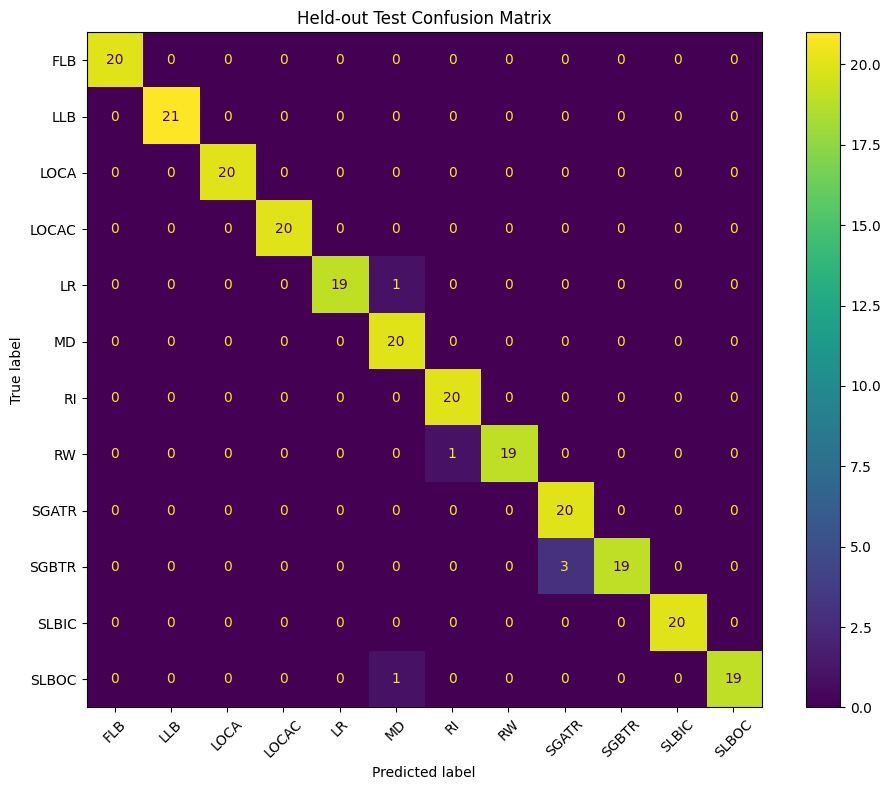

In [ ]:
labels = sorted(set(y_test))

cm = confusion_matrix(y_test, y_test_pred, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Held-out Test Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Practical checks before publishing

In [ ]:
print("Leakage checks:")
print("- Common numeric columns learned from training only.")
print("- Scaler fit on training only.")
print("- Low-variance mask learned from training only.")
print("- Pearson clusters learned from training only.")
print("- Cluster ranking and subset selection performed on validation only.")
print("- Test set used only for final evaluation.")

Leakage checks:
- Common numeric columns learned from training only.
- Scaler fit on training only.
- Low-variance mask learned from training only.
- Pearson clusters learned from training only.
- Cluster ranking and subset selection performed on validation only.
- Test set used only for final evaluation.
